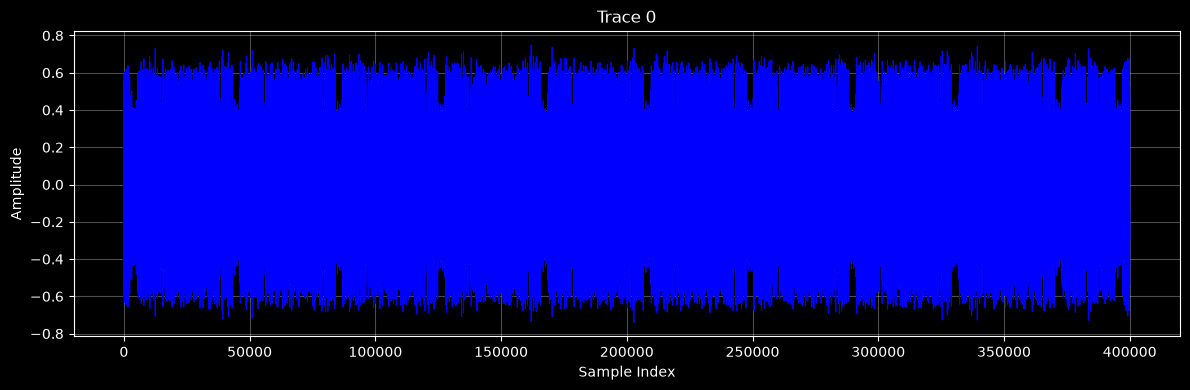

SNR: 100%|██████████| 3/3 [00:00<00:00,  7.71it/s]


In [1]:
from scapyter.domain.leakage_functions.leakage_functions import HammingWeight
from scapyter.domain.leakage_model.leakage_model import LeakageModel
import numpy as np

from scapyter.domain.analysis.snr.snr_service import SnrService
from scapyter.domain.targets.targets import SboxOutput
from scapyter.domain.value_object import RangeParameters, Range, DataSource, KeyByteGuesses
from scapyter.infrastructure.h5_project_file_reader import H5ProjectFileReader
from scapyter.ui.snr_plotter import SnrPlotter
from scapyter.ui.trace_plotter import TracePlotter

file_path = "../../data/smart-card-project/smart_card_project.sx"

project = H5ProjectFileReader(file_path)
trace_plotter = TracePlotter(project)
trace_plotter.plot_single(index=0)

range_parameter = RangeParameters(
    trace_range=Range(0, project.trace_count),
    sample_range=Range(0, project.sample_count),
)


known_key = project.get_single_batch(1).key


snr_service = SnrService(range_parameters=range_parameter,
                         data_source=DataSource.PLAINTEXT,
                         project_file_reader=project
                         )
results: dict[int, np.ndarray] = {}
for i in range(5):
    leakage_model = LeakageModel(
            target=SboxOutput(),
            leakage_function=HammingWeight(),
            byte_location=i,
            key_byte_guesses=KeyByteGuesses(values=[known_key[i]])
        )
    result = snr_service.run(leakage_model=leakage_model)
    results[i] = result


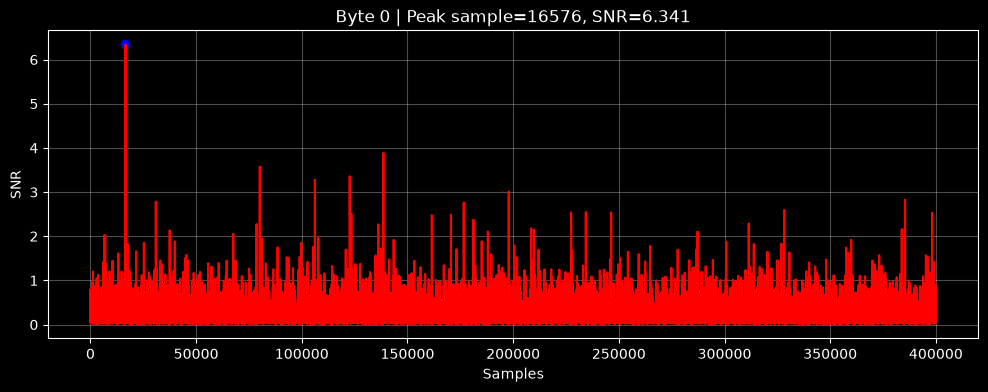

In [2]:
plotter = SnrPlotter(results)
plotter.plot_byte(0)

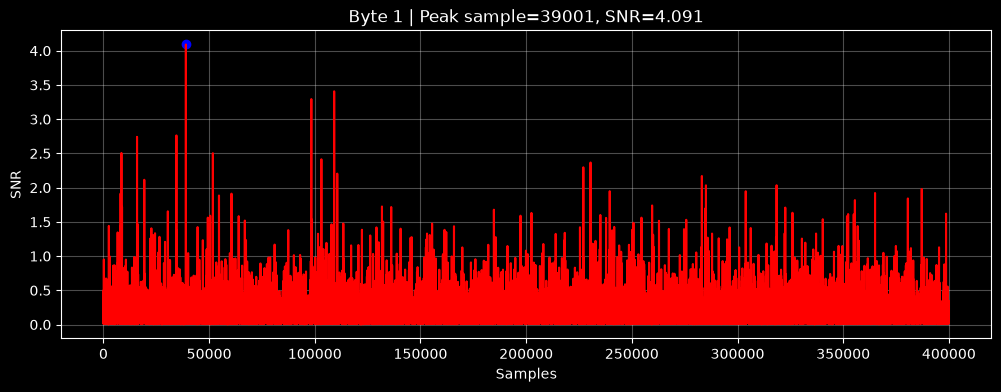

In [3]:
plotter = SnrPlotter(results)
plotter.plot_byte(1)